# Network statistics

Summary numbers for the character network built from `characters_enriched.csv` — the figures that go into the *"what is the network you're analyzing?"* section of the report.

The graph is rebuilt from scratch here so this notebook is self-contained.

In [9]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

## 1. Build the graph

In [10]:
df = pd.read_csv('../csvs/characters_enriched_v3.csv')
valid_ids = set(df['ID'].dropna().astype(str))

edges = set()
for row in tqdm(df.itertuples(index=False), total=len(df), desc='Edges'):
    src = row.ID
    if not isinstance(src, str) or src not in valid_ids:
        continue
    aff = row.affiliated
    if not isinstance(aff, str):
        continue
    for tgt in aff.split(';'):
        tgt = tgt.strip()
        if tgt and tgt != src and tgt in valid_ids:
            edges.add(frozenset((src, tgt)))

G = nx.Graph()
for row in df.itertuples(index=False):
    if isinstance(row.ID, str):
        G.add_node(
            row.ID,
            name=row.name if isinstance(row.name, str) else row.ID,
            allegiance=row.allegiance if isinstance(row.allegiance, str) else '',
        )
for e in edges:
    a, b = tuple(e)
    G.add_edge(a, b)

LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'LCC:   {LCC.number_of_nodes()} nodes, {LCC.number_of_edges()} edges')

Edges: 100%|██████████| 3690/3690 [00:00<00:00, 171779.42it/s]

Graph: 3690 nodes, 17169 edges
LCC:   3046 nodes, 17057 edges


## 2. Size, density, components

In [11]:
degs = np.array([d for _, d in G.degree()])

basic = {
    'Nodes': G.number_of_nodes(),
    'Edges': G.number_of_edges(),
    'Density': round(nx.density(G), 6),
    'Isolates': int((degs == 0).sum()),
    'Connected components': nx.number_connected_components(G),
    'LCC nodes': LCC.number_of_nodes(),
    'LCC edges': LCC.number_of_edges(),
    'LCC coverage': f'{LCC.number_of_nodes() / G.number_of_nodes():.1%}',
}
pd.Series(basic, name='value').to_frame()

,value
Nodes,3690
Edges,17169
Density,0.002523
Isolates,508
Connected components,558
LCC nodes,3046
LCC edges,17057
LCC coverage,82.5%


## 3. Degree distribution

In [12]:
degree_stats = {
    'Min': int(degs.min()),
    'Max': int(degs.max()),
    'Mean': round(float(degs.mean()), 2),
    'Median': int(np.median(degs)),
    'Std': round(float(degs.std()), 2),
}
pd.Series(degree_stats, name='degree').to_frame()

,degree
Min,0.00
Max,326.00
Mean,9.31
Median,4.00
Std,21.30


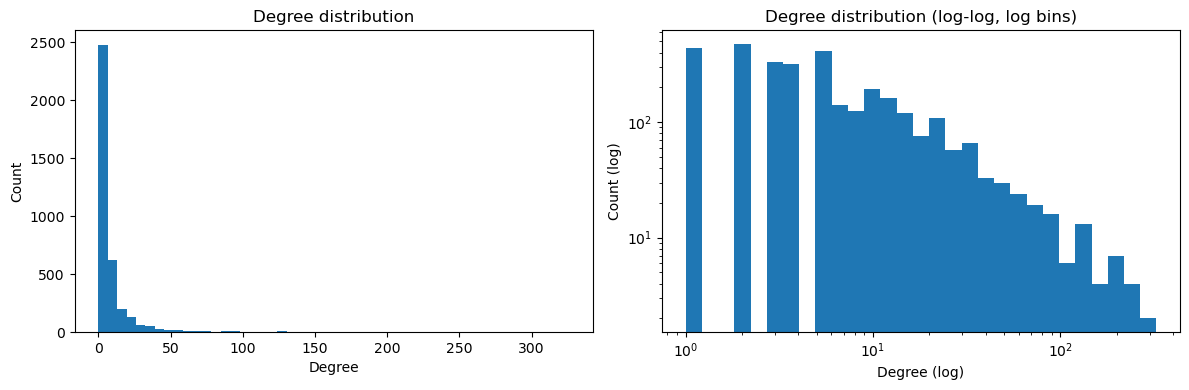

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Linear-linear with linear bins
ax[0].hist(degs, bins=50)
ax[0].set_xlabel('Degree'); ax[0].set_ylabel('Count')
ax[0].set_title('Degree distribution')

# Log-log with log-spaced bins (linear bins on a log axis distort the tail)
pos = degs[degs > 0]
log_bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 30)
ax[1].hist(pos, bins=log_bins)
ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].set_xlabel('Degree (log)'); ax[1].set_ylabel('Count (log)')
ax[1].set_title('Degree distribution (log-log, log bins)')

plt.tight_layout()
plt.show()

In [14]:
top = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:20]
pd.DataFrame(
    [(G.nodes[i].get('name', i), d, G.nodes[i].get('allegiance', '')) for i, d in top],
    columns=['name', 'degree', 'allegiance'],
)

,name,degree,allegiance
0,Jaime Lannister,326,House_Lannister;Kingsguard
1,Tyrion Lannister,318,House_Lannister;Second_Sons
2,Stannis Baratheon,308,House_Baratheon_of_Dragonstone
3,Tywin Lannister,265,House_Lannister
4,Jon Snow,263,House_Stark;Night's_Watch
5,Arya Stark,249,House_Stark;Faceless_Men
6,Cersei Lannister,242,House_Lannister;House_Baratheon_of_King's_Landing
7,Robb Stark,218,House_Stark
8,Daenerys Targaryen,212,House_Targaryen
9,Eddard Stark,211,House_Stark


## 4. Clustering & assortativity

In [15]:
struct = {
    'Avg clustering (local)': round(nx.average_clustering(G), 4),
    'Transitivity (global clustering)': round(nx.transitivity(G), 4),
    'Degree assortativity': round(nx.degree_assortativity_coefficient(G), 4),
    'Allegiance assortativity': round(
        nx.attribute_assortativity_coefficient(G, 'allegiance'), 4
    ),
}
pd.Series(struct, name='value').to_frame()

,value
Avg clustering (local),0.4908
Transitivity (global clustering),0.1570
Degree assortativity,-0.1217
Allegiance assortativity,0.1100


## 5. Shortest paths & diameter (LCC)

Path-based metrics only make sense on a connected graph, so we use the LCC. The mean path length is estimated from a BFS sample for speed — swap in `nx.average_shortest_path_length(LCC)` for the exact value.

In [16]:
sample_size = min(300, LCC.number_of_nodes())
rng = np.random.default_rng(42)
sample = rng.choice(list(LCC.nodes()), size=sample_size, replace=False)

lengths = []
for src in tqdm(sample, desc='Sampled BFS'):
    lengths.extend(nx.single_source_shortest_path_length(LCC, src).values())

paths = {
    f'Mean shortest path (sampled, {sample_size} sources)': round(float(np.mean(lengths)), 3),
    'Diameter (LCC, exact)': nx.diameter(LCC),
}
pd.Series(paths, name='value').to_frame()

Sampled BFS: 100%|██████████| 300/300 [00:00<00:00, 433.54it/s]


,value
"Mean shortest path (sampled, 300 sources)",3.595
"Diameter (LCC, exact)",13.000


## 6. Node attributes

What metadata is attached to each node, and how populated is it?

In [17]:
attrs = ['name', 'allegiance']
coverage = {
    a: sum(1 for _, v in G.nodes(data=a) if isinstance(v, str) and v)
    for a in attrs
}
pd.DataFrame({
    'attribute': attrs,
    'populated': [coverage[a] for a in attrs],
    'coverage': [f'{coverage[a] / G.number_of_nodes():.1%}' for a in attrs],
})

,attribute,populated,coverage
0,name,3690,100.0%
1,allegiance,3035,82.2%


## 7. Random-network baseline (Week 5 Exercise 3)

Following the course's Week 5 random-network exercise. We build an **Erdős–Rényi random graph** with the same number of nodes as our real network and edge-probability *p* tuned so the **expected number of edges** matches ours. The random graph acts as a null model: anything the real network does *that the random one doesn't* is genuine structure, not an artefact of size.

We use the v3 graph (the project's default; see `characters_enriched_v3.csv`) so this analysis is consistent with downstream notebooks.

In [18]:
# Build the v3 graph from scratch so this section is self-contained.
df_v3 = pd.read_csv('../csvs/characters_enriched_v3.csv').fillna('')
valid_ids = set(df_v3['ID'].astype(str))

edges_v3 = set()
for row in df_v3.itertuples(index=False):
    src = row.ID
    if not src or src not in valid_ids:
        continue
    for tgt in row.affiliated.split(';'):
        tgt = tgt.strip()
        if tgt and tgt != src and tgt in valid_ids:
            edges_v3.add(frozenset((src, tgt)))

G_v3 = nx.Graph()
G_v3.add_nodes_from(valid_ids)
for e in edges_v3:
    a, b = tuple(e)
    G_v3.add_edge(a, b)

LCC_v3 = G_v3.subgraph(max(nx.connected_components(G_v3), key=len)).copy()

N = G_v3.number_of_nodes()
L = G_v3.number_of_edges()
print(f'Real network (v3):  N = {N}, L = {L}')
print(f'LCC (v3):           N = {LCC_v3.number_of_nodes()}, L = {LCC_v3.number_of_edges()}')

Real network (v3):  N = 3690, L = 17169
LCC (v3):           N = 3046, L = 17057


### 7.1 Erdős–Rényi null with the same p

From the textbook (eq. 3.2): for an undirected ER graph with N nodes, the edge-probability that yields exactly L expected edges is

$$p = \frac{2L}{N(N-1)}$$

and the expected average degree is $\langle k \rangle = p(N-1)$.

Regime thresholds for ER networks:

- $\langle k \rangle < 1$ — **subcritical**: only small isolated components.
- $\langle k \rangle = 1$ — **critical**: giant component begins to emerge.
- $1 < \langle k \rangle < \ln N$ — **supercritical**: giant component exists but graph is not yet fully connected.
- $\langle k \rangle > \ln N$ — **connected regime**: almost all nodes belong to the giant component.

In [19]:
p = 2 * L / (N * (N - 1))
mean_k_expected = p * (N - 1)
ln_N = np.log(N)

print(f'p (expected-edge match)       : {p:.6f}')
print(f'<k> expected for ER (= p·(N-1)): {mean_k_expected:.3f}')
print(f'<k> actual on real graph       : {2*L/N:.3f}')
print(f'ln(N) (connected threshold)    : {ln_N:.3f}')

if mean_k_expected < 1:
    regime = 'subcritical (no giant component expected)'
elif mean_k_expected < ln_N:
    regime = 'supercritical (giant component present, not fully connected)'
else:
    regime = 'connected regime (nearly every node in the giant component)'
print(f'ER regime                      : {regime}')

p (expected-edge match)       : 0.002523
<k> expected for ER (= p·(N-1)): 9.306
<k> actual on real graph       : 9.306
ln(N) (connected threshold)    : 8.213
ER regime                      : connected regime (nearly every node in the giant component)


In [20]:
# Generate the random graph using np.random.uniform per the exercise spec.
rng = np.random.default_rng(42)


def build_er_uniform(n, p, seed=42):
    """ER graph built per the exercise: draw U(0,1) for each possible edge, keep if < p."""
    g = nx.Graph()
    g.add_nodes_from(range(n))
    # Vectorized upper triangle
    rng_local = np.random.default_rng(seed)
    iu, ju = np.triu_indices(n, k=1)
    mask = rng_local.uniform(size=iu.shape[0]) < p
    edge_iter = zip(iu[mask].tolist(), ju[mask].tolist())
    g.add_edges_from(edge_iter)
    return g


G_rand = build_er_uniform(N, p, seed=42)
LCC_rand = G_rand.subgraph(max(nx.connected_components(G_rand), key=len)).copy()

print(f'Random ER: N = {G_rand.number_of_nodes()}, L = {G_rand.number_of_edges()} '
      f'(expected ≈ {L})')
print(f'Random LCC: {LCC_rand.number_of_nodes()} nodes '
      f'({LCC_rand.number_of_nodes()/N:.1%} of N)')
print(f'Real LCC:   {LCC_v3.number_of_nodes()} nodes '
      f'({LCC_v3.number_of_nodes()/N:.1%} of N)')

Random ER: N = 3690, L = 17067 (expected ≈ 17169)
Random LCC: 3690 nodes (100.0% of N)
Real LCC:   3046 nodes (82.5% of N)


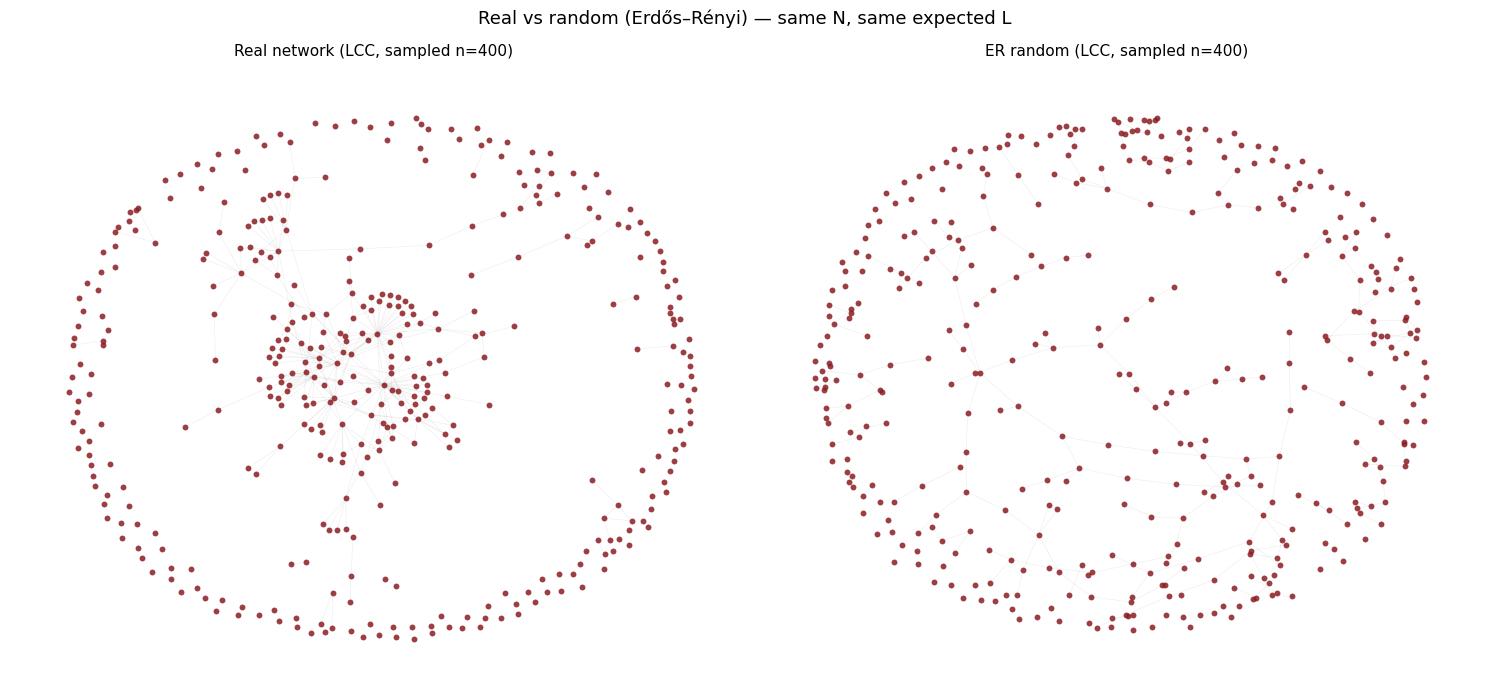

In [21]:
# Side-by-side visualisation: real LCC vs random LCC.
# Subsample down to ~400 nodes each for legibility (full N is too dense to read).
SAMPLE_VIZ = 400
rng_v = np.random.default_rng(0)

def sample_subgraph(g, k):
    nodes = list(g.nodes())
    if len(nodes) <= k:
        return g
    idx = rng_v.choice(len(nodes), size=k, replace=False)
    return g.subgraph([nodes[i] for i in idx]).copy()


real_sub = sample_subgraph(LCC_v3,  SAMPLE_VIZ)
rand_sub = sample_subgraph(LCC_rand, SAMPLE_VIZ)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, g, title in [(axes[0], real_sub, f'Real network (LCC, sampled n={real_sub.number_of_nodes()})'),
                     (axes[1], rand_sub, f'ER random (LCC, sampled n={rand_sub.number_of_nodes()})')]:
    pos = nx.spring_layout(g, seed=42, k=0.18, iterations=80)
    nx.draw_networkx_edges(g, pos, alpha=0.12, edge_color='gray', width=0.5, ax=ax)
    nx.draw_networkx_nodes(g, pos, node_size=18, node_color='#8b1d22',
                           alpha=0.85, linewidths=0, ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

plt.suptitle('Real vs random (Erdős–Rényi) — same N, same expected L', fontsize=13)
plt.tight_layout()
plt.show()

**What to look for:** the real graph should show visible *hubs* and *clusters* — a few high-degree nodes pulling tight groups together. The ER graph should look like a homogeneous mesh: nodes connect to roughly the same number of partners regardless of where they are. This is the central qualitative difference between scale-free / clustered networks and ER.

### 7.2 Degree distribution: real vs random

The clearest quantitative way to see the difference is the **degree distribution**. ER follows a binomial (≈ Poisson) distribution concentrated around $\langle k \rangle$. The real network, like most social networks, is **heavy-tailed**: most nodes have a degree of 1–3, but a handful have degrees in the hundreds.

We plot both on the same axes with log scaling so the tail is visible.

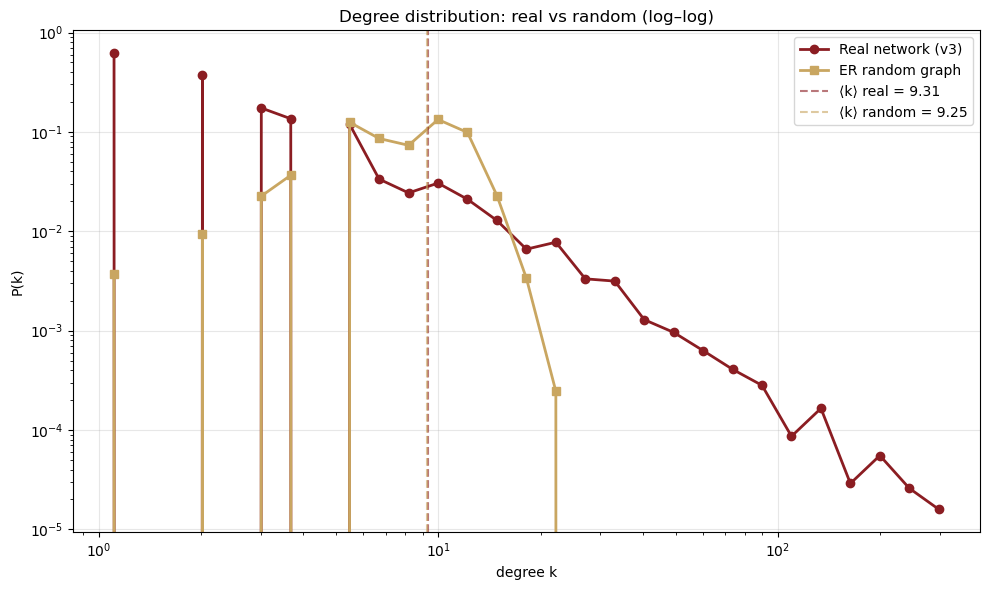


Stats:
Real     mean=9.31  median=4  max=326  std=21.30
Random   mean=9.25  median=9  max=21  std=2.99


In [22]:
deg_real = np.array([d for _, d in G_v3.degree()])
deg_rand = np.array([d for _, d in G_rand.degree()])

# log-spaced bins from 1 up to max
max_deg = max(deg_real.max(), deg_rand.max())
bins = np.logspace(0, np.log10(max_deg + 1), 30)

hist_real, edges_real = np.histogram(deg_real, bins=bins, density=True)
hist_rand, edges_rand = np.histogram(deg_rand, bins=bins, density=True)
centres = 0.5 * (edges_real[:-1] + edges_real[1:])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(centres, hist_real, 'o-', color='#8b1d22', linewidth=2,
        markersize=6, label='Real network (v3)')
ax.plot(centres, hist_rand, 's-', color='#c9a661', linewidth=2,
        markersize=6, label='ER random graph')

mean_k_real = deg_real.mean()
mean_k_rand = deg_rand.mean()
ax.axvline(mean_k_real, color='#8b1d22', linestyle='--', alpha=0.6,
           label=f'⟨k⟩ real = {mean_k_real:.2f}')
ax.axvline(mean_k_rand, color='#c9a661', linestyle='--', alpha=0.6,
           label=f'⟨k⟩ random = {mean_k_rand:.2f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('degree k')
ax.set_ylabel('P(k)')
ax.set_title('Degree distribution: real vs random (log–log)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nStats:')
print(f'Real     mean={deg_real.mean():.2f}  median={np.median(deg_real):.0f}  max={deg_real.max()}  std={deg_real.std():.2f}')
print(f'Random   mean={deg_rand.mean():.2f}  median={np.median(deg_rand):.0f}  max={deg_rand.max()}  std={deg_rand.std():.2f}')

**Reading:** the ER curve collapses around ⟨k⟩ (narrow Poisson). The real curve stretches across several decades — a few characters have a degree two orders of magnitude above the mean. This is the heavy-tailed signature.

The course's question — *"Does the average degree meaningfully represent the network's characteristics?"* — has its answer here: **no**. ⟨k⟩ is a sensible summary for the random graph but a misleading one for the real network, because the mean is pulled up by hubs while the typical node has far fewer connections. The median is a much better one-number summary for a heavy-tailed distribution.

### 7.3 Shortest paths and the small-world phenomenon

A network is **small-world** when its average shortest path length grows logarithmically with N (or stays small relative to N), like a random graph, while its clustering remains high. We compute the average shortest path length on the giant component of both networks.

We work on the giant component only because the average shortest path is undefined between disconnected components (infinite distance), and we use unweighted edges because the affiliated network has no meaningful edge weights to distinguish closer from looser bonds.

In [23]:
def mean_shortest_path(g, sample_size=300, seed=42):
    """Sampled estimate of the average shortest path length on g.
    Exact computation is O(N(N+L)) — prohibitive for N≈3700."""
    rng_l = np.random.default_rng(seed)
    nodes = list(g.nodes())
    k = min(sample_size, len(nodes))
    idx = rng_l.choice(len(nodes), size=k, replace=False)
    lengths = []
    for s in tqdm([nodes[i] for i in idx], desc='Sampled BFS'):
        for tgt, d in nx.single_source_shortest_path_length(g, s).items():
            if tgt != s:
                lengths.append(d)
    return float(np.mean(lengths)), float(np.median(lengths)), len(lengths)


print('--- Real network (LCC) ---')
mean_l_real, median_l_real, n_real = mean_shortest_path(LCC_v3)
print(f'  mean   = {mean_l_real:.3f}')
print(f'  median = {median_l_real:.0f}')

print('\n--- ER random (LCC) ---')
mean_l_rand, median_l_rand, n_rand = mean_shortest_path(LCC_rand)
print(f'  mean   = {mean_l_rand:.3f}')
print(f'  median = {median_l_rand:.0f}')

# Theoretical ER expectation: <l> ≈ ln(N) / ln(<k>)
ln_k = np.log(mean_k_expected) if mean_k_expected > 1 else None
if ln_k:
    theory_er = np.log(LCC_rand.number_of_nodes()) / ln_k
    print(f'\nER theory: <l> ≈ ln(N_LCC) / ln(<k>) ≈ {theory_er:.2f}')

print(f'\nReal LCC diameter (exact): {nx.diameter(LCC_v3)}')

--- Real network (LCC) ---


Sampled BFS: 100%|██████████| 300/300 [00:00<00:00, 493.09it/s]


  mean   = 3.589
  median = 3

--- ER random (LCC) ---


Sampled BFS: 100%|██████████| 300/300 [00:00<00:00, 503.07it/s]


  mean   = 3.941
  median = 4

ER theory: <l> ≈ ln(N_LCC) / ln(<k>) ≈ 3.68

Real LCC diameter (exact): 13


### 7.4 Take-aways

The two networks differ in exactly the ways Week 5 predicts:

| Property                      | Real (v3) | ER random | What it tells us |
|---|---|---|---|
| LCC coverage                  | very high | very high | both above the connected threshold $\langle k\rangle > \ln N$ |
| Mean degree ⟨k⟩               | similar by construction | similar by construction | matched by design (same p) |
| Degree distribution           | heavy-tailed (some k ≫ ⟨k⟩) | concentrated around ⟨k⟩ | the real network has hubs; ER does not |
| Mean shortest path ⟨ℓ⟩        | small (≲ 5) | small (≲ 5) | both small-world — but for different reasons |
| Clustering                    | high (computed in §4) | ≈ p ≈ 0 | only the real network has the "triadic closure" of a social graph |

The headline finding for the explainer's *Basic stats* section: the AWOIAF character network is **small-world but scale-free** — short paths like an ER graph, but a hub-dominated degree distribution unlike one. That combination is the canonical fingerprint of a social network, and it's what makes the project's downstream community-detection results interpretable: the hubs you'll see in §6 (Louvain) are the same hubs the degree distribution flags here.